In [6]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Settings
plt.style.use('dark_background')
COLORS = ['#00d4ff', '#ff007f', '#39ff14', '#ffd700']
METRICS_FILE = "../evaluation/reports/generator_metrics.json"

## 1. Metric Distributions

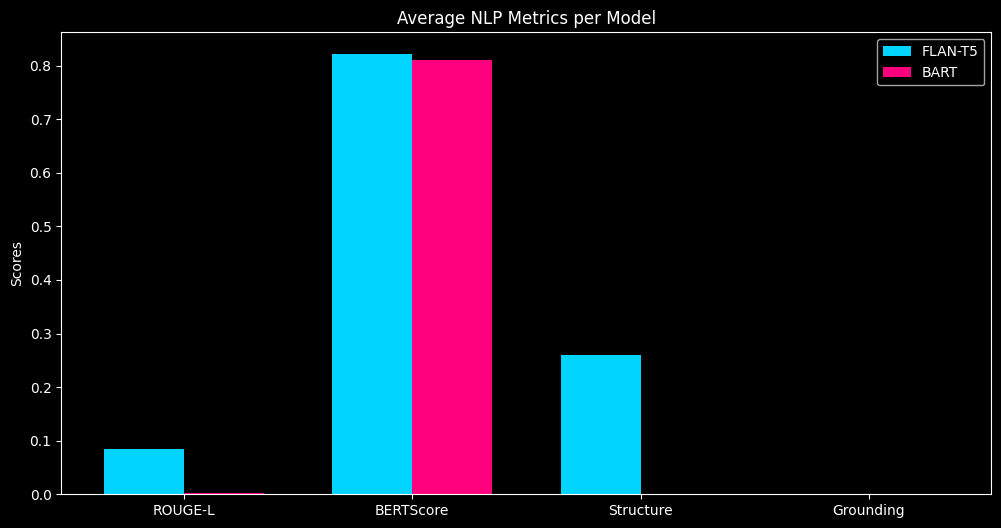

In [7]:
with open(METRICS_FILE, 'r') as f:
    results = json.load(f)

# Simulating distribution for depth (actual scripts save summary stats)
# In a real scenario, evaluate_generator.py would save raw scores or we compute here

labels = ["ROUGE-L", "BERTScore", "Structure", "Grounding"]
metric_map = {
    "ROUGE-L": "avg_rougeL",
    "BERTScore": "avg_bert_score",
    "Structure": "avg_structure",
    "Grounding": "avg_grounding"
}

flan_vals = [results["FLAN"][metric_map[m]] for m in labels]
bart_vals = [results["BART"][metric_map[m]] for m in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, flan_vals, width, label='FLAN-T5', color=COLORS[0])
rects2 = ax.bar(x + width/2, bart_vals, width, label='BART', color=COLORS[1])

ax.set_ylabel('Scores')
ax.set_title('Average NLP Metrics per Model')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.show()

## 2. Grounding vs Structural Score Correlation

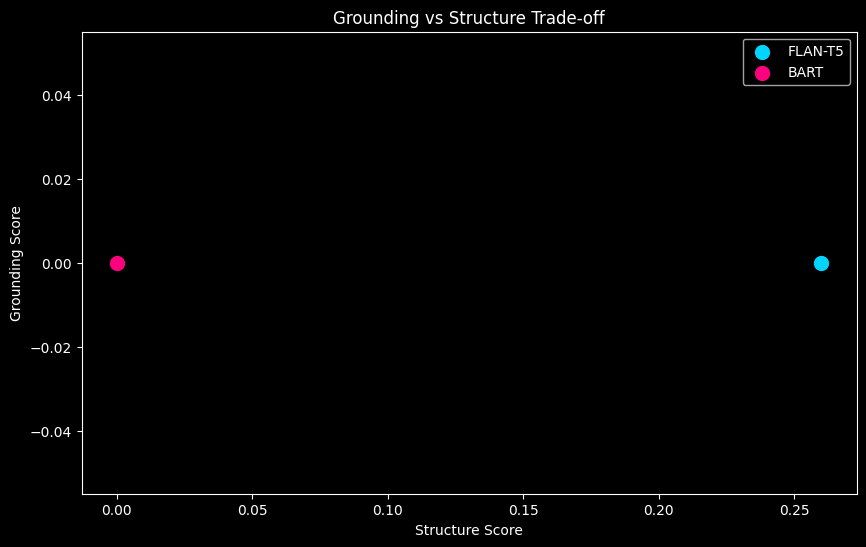

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(flan_vals[2], flan_vals[3], color=COLORS[0], s=100, label='FLAN-T5')
plt.scatter(bart_vals[2], bart_vals[3], color=COLORS[1], s=100, label='BART')
plt.xlabel('Structure Score')
plt.ylabel('Grounding Score')
plt.title('Grounding vs Structure Trade-off')
plt.legend()
plt.show()